In [31]:
library(tidyverse)

# Open your file (adjust path + separator if needed)
df <- read.table(
  #"/home/mjehangir/sv_annotation.txt",
      "/home/mjehangir/complex_event.txt",

  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
)

# Inspect first rows
head(df)

,Samples,Templated.Insertion.Chains..TICs..like.complex.insertions,chromothripsis,foldback.translocation,complex.rearranegment.single.chr,complex.rearranegment.multiple.chr,chromoplexy,X
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,3188,chr6,"(chr5,chr14)","(chr20,chr11)",chr13,,,NA
2,3988,"(chr2,chr5)",,,"chr1,chr2,chr3",,,NA
3,6265D,,chr5,1,"chr18,chr3,chr13","(chr12,chr17)",,NA
4,6266D,,,,chr10,"chr3,chr9",,NA
5,6277A,"(chr1, chr2)(chr9,chr8.chr7)(chr9,chr16),chr12,(chr20,chr8)","chr13,chr2","(chr18,chr14)(chr18,chr4)",chr8,"(chr6,chr10.chr19),(chr10,chr13,chr18)(chr2,chr10,chr6)(chr7,chr8,chr9)(chr12,chr13.chr5)","chr18,chr3,chr7,chr8,chr9",NA
6,6314E,"(chr11.chr22)(chr19,chr14)",,,,,,NA


In [32]:
colnames(df)
head(df)


[1] "Samples"                                                  
[2] "Templated.Insertion.Chains..TICs..like.complex.insertions"
[3] "chromothripsis"                                           
[4] "foldback.translocation"                                   
[5] "complex.rearranegment.single.chr"                         
[6] "complex.rearranegment.multiple.chr"                       
[7] "chromoplexy"                                              
[8] "X"

,Samples,Templated.Insertion.Chains..TICs..like.complex.insertions,chromothripsis,foldback.translocation,complex.rearranegment.single.chr,complex.rearranegment.multiple.chr,chromoplexy,X
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,3188,chr6,"(chr5,chr14)","(chr20,chr11)",chr13,,,NA
2,3988,"(chr2,chr5)",,,"chr1,chr2,chr3",,,NA
3,6265D,,chr5,1,"chr18,chr3,chr13","(chr12,chr17)",,NA
4,6266D,,,,chr10,"chr3,chr9",,NA
5,6277A,"(chr1, chr2)(chr9,chr8.chr7)(chr9,chr16),chr12,(chr20,chr8)","chr13,chr2","(chr18,chr14)(chr18,chr4)",chr8,"(chr6,chr10.chr19),(chr10,chr13,chr18)(chr2,chr10,chr6)(chr7,chr8,chr9)(chr12,chr13.chr5)","chr18,chr3,chr7,chr8,chr9",NA
6,6314E,"(chr11.chr22)(chr19,chr14)",,,,,,NA


Warning message in data.frame(Sample = s_id, Chromosome = chrs, Type = label):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(Sample = s_id, Chromosome = chrs, Type = label):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(Sample = s_id, Chromosome = chrs, Type = label):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(Sample = s_id, Chromosome = chrs, Type = label):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(Sample = s_id, Chromosome = chrs, Type = label):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(Sample = s_id, Chromosome = chrs, Type = label):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(Sample = s_id, Chromosome = chrs, Type = label):
“row names were found from a shor

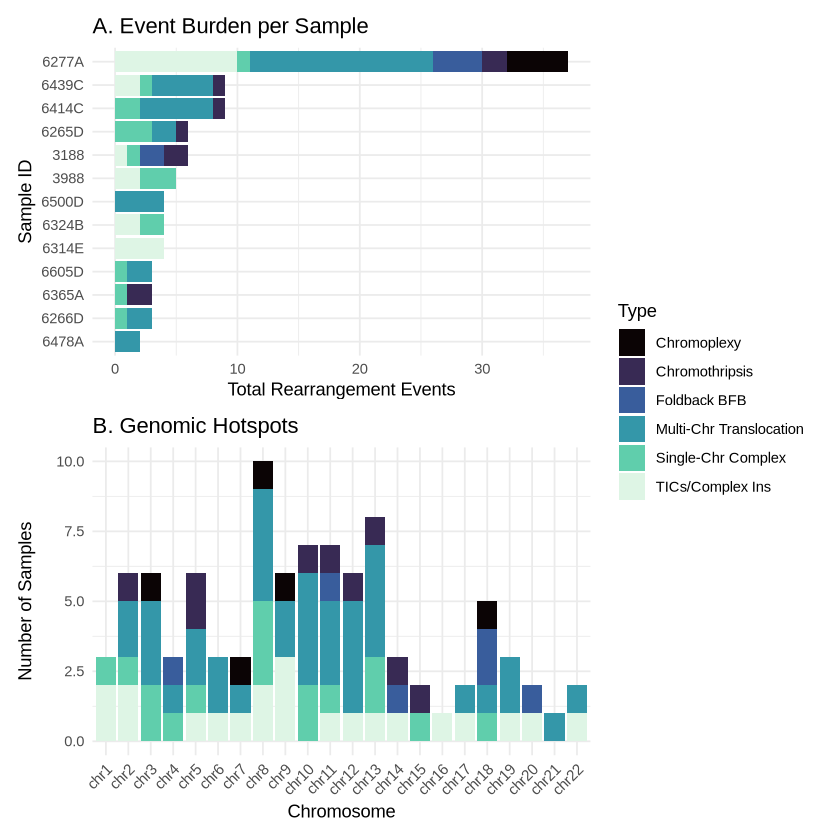

In [33]:
# Load necessary libraries
library(ggplot2)
library(dplyr)
library(tidyr)
library(stringr)
library(patchwork) # For combining plots

# 1. Comprehensive Parsing (Handles your new columns)
process_all_events <- function(row) {
  s_id <- row['Samples']
  
  extract_type <- function(val, label) {
    if (is.na(val) || val == "") return(NULL)
    chrs <- unlist(str_extract_all(val, "chr[0-9XY]+"))
    if(length(chrs) > 0) return(data.frame(Sample=s_id, Chromosome=chrs, Type=label))
    return(NULL)
  }
  
  bind_rows(
    extract_type(row['Templated.Insertion.Chains..TICs..like.complex.insertions'], "TICs/Complex Ins"),
    extract_type(row['chromothripsis'], "Chromothripsis"),
    extract_type(row['foldback.translocation'], "Foldback BFB"),
    extract_type(row['complex.rearranegment.single.chr'], "Single-Chr Complex"),
    extract_type(row['complex.rearranegment.multiple.chr'], "Multi-Chr Translocation"),
    extract_type(row['chromoplexy'], "Chromoplexy")
  )
}

# Apply to your new df
summary_df <- bind_rows(apply(df, 1, process_all_events))
chr_order <- paste0("chr", c(1:22, "X", "Y"))
summary_df$Chromosome <- factor(summary_df$Chromosome, levels = chr_order)

# 2. Plot A: Sample Burden (Which sample has the most events?)
plot_burden <- ggplot(summary_df, aes(x = reorder(Sample, Sample, function(x) length(x)), fill = Type)) +
  geom_bar() +
  coord_flip() +
  scale_fill_viridis_d(option = "mako") +
  theme_minimal() +
  labs(title = "A. Event Burden per Sample", x = "Sample ID", y = "Total Rearrangement Events")

# 3. Plot B: Chromosome Hotspots (Where are these events happening?)
plot_hotspots <- ggplot(summary_df, aes(x = Chromosome, fill = Type)) +
  geom_bar() +
  scale_fill_viridis_d(option = "mako") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "B. Genomic Hotspots", x = "Chromosome", y = "Number of Samples")

# 4. Combine them into one dashboard
final_panel <- plot_burden / plot_hotspots + plot_layout(guides = 'collect')
print(final_panel)

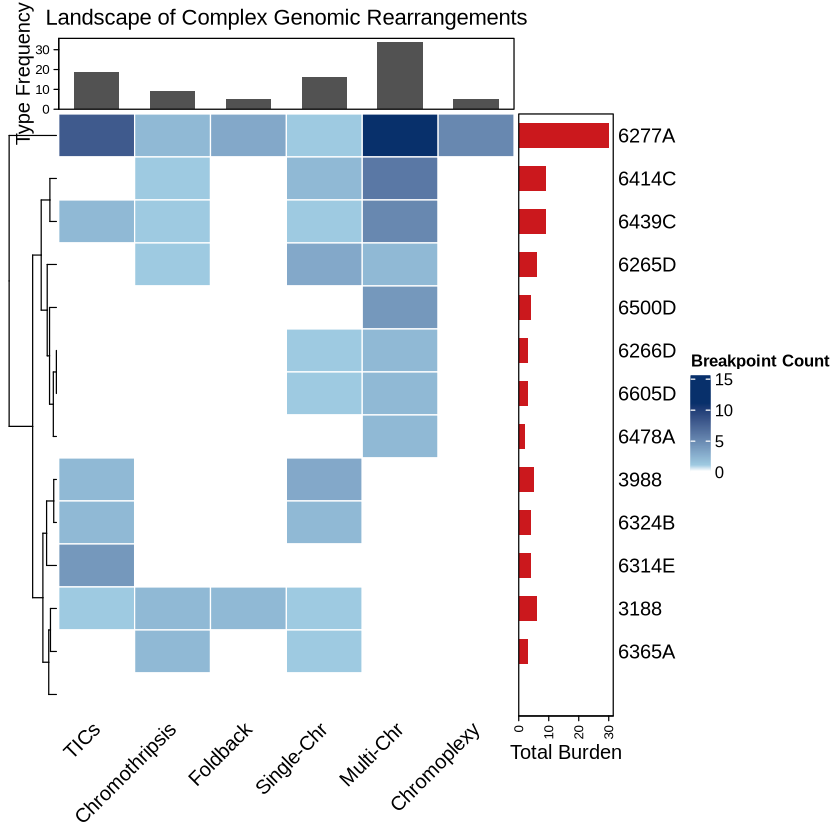

In [34]:
# 1. Load libraries (suppressing messages for a clean console)
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(dplyr)
  library(stringr)
})

# --- 2. DATA PROCESSING ---
parse_count <- function(text) {
  if (is.na(text) || text == "" || is.logical(text)) return(0)
  # Extract unique chromosome mentions
  chrs <- unlist(str_extract_all(as.character(text), "chr[0-9XY]+"))
  return(length(unique(chrs)))
}

# Transform 'df' into a clean numeric matrix
plot_df <- df %>%
  rowwise() %>%
  mutate(
    TICs = parse_count(Templated.Insertion.Chains..TICs..like.complex.insertions),
    Chromothripsis = parse_count(chromothripsis),
    Foldback = parse_count(foldback.translocation),
    `Single-Chr` = parse_count(complex.rearranegment.single.chr),
    `Multi-Chr` = parse_count(complex.rearranegment.multiple.chr),
    Chromoplexy = parse_count(chromoplexy)
  ) %>%
  ungroup()

# FORCE NUMERIC: This fixes the "non-numeric argument" error
mat <- plot_df %>% 
  select(TICs, Chromothripsis, Foldback, `Single-Chr`, `Multi-Chr`, Chromoplexy) %>%
  as.matrix()

# Ensure all NAs are 0 and all values are numeric
mat[is.na(mat)] <- 0
class(mat) <- "numeric" 
rownames(mat) <- plot_df$Samples

# --- 3. THE VISUAL STYLE ---
# Calculate max safely
max_val <- max(mat, na.rm = TRUE)
if(max_val == 0) max_val <- 1 # Avoid color scale crash if all zeros

col_fun = colorRamp2(c(0, 1, max_val), c("#ffffff", "#9ecae1", "#08306b"))

top_ha = HeatmapAnnotation(
  "Type Frequency" = anno_barplot(colSums(mat), gp = gpar(fill = "#525252", col = NA)),
  annotation_name_side = "left", height = unit(1.5, "cm")
)

right_ha = rowAnnotation(
  "Total Burden" = anno_barplot(rowSums(mat), gp = gpar(fill = "#cb181d", col = NA)),
  width = unit(2, "cm")
)

# --- 4. FINAL PLOT ---
final_plot = Heatmap(mat, 
        name = "Breakpoint Count", 
        col = col_fun,
        rect_gp = gpar(col = "white", lwd = 1), 
        cluster_rows = TRUE, 
        cluster_columns = FALSE,
        clustering_method_rows = "ward.D2",
        top_annotation = top_ha,
        right_annotation = right_ha,
        column_title = "Landscape of Complex Genomic Rearrangements",
        column_names_rot = 45)

draw(final_plot)

In [35]:
# Open your file (adjust path + separator if needed)
clinic <- read.table(
  #"/home/mjehangir/sv_annotation.txt",
      "/home/mjehangir/telomere-sv-analysis/data/clinical_data.txt",

  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
)

# Inspect first rows
head(clinic)

,ID,Age,Grade,CDKN2A.B,TP53,ATRX,onco_Alterations,ONT_Alterations
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2436A,NA,3,NA,NA,NA,5,40
2,3188,NA,3,NA,NA,NA,16,107
3,3988,0,2,2,0,0,17,105
4,6265D,33,3,1,0,0,42,87
5,6266D,40,2,1,0,0,28,105
6,6269C,23,3,2,0,0,14,214


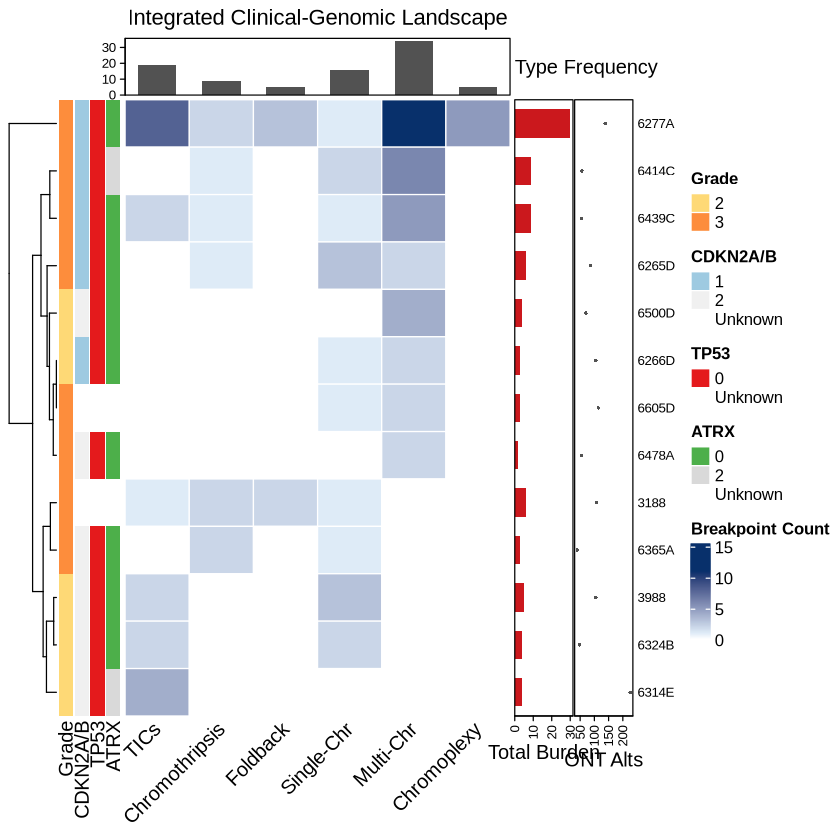

In [41]:
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(dplyr)
  library(stringr)
})

# --- 1. DATA PREPARATION ---
parse_count <- function(text) {
  if (is.na(text) || text == "" || is.logical(text)) return(0)
  chrs <- unlist(str_extract_all(as.character(text), "chr[0-9XY]+"))
  return(length(unique(chrs)))
}

genomic_df <- df %>%
  rowwise() %>%
  mutate(
    TICs = parse_count(Templated.Insertion.Chains..TICs..like.complex.insertions),
    Chromothripsis = parse_count(chromothripsis),
    Foldback = parse_count(foldback.translocation),
    `Single-Chr` = parse_count(complex.rearranegment.single.chr),
    `Multi-Chr` = parse_count(complex.rearranegment.multiple.chr),
    Chromoplexy = parse_count(chromoplexy)
  ) %>%
  ungroup()

# Merge clinical and genomic
combined_df <- genomic_df %>%
  inner_join(clinic, by = c("Samples" = "ID"))

# Create numeric matrix
mat <- combined_df %>% 
  select(TICs, Chromothripsis, Foldback, `Single-Chr`, `Multi-Chr`, Chromoplexy) %>%
  as.matrix()
mat[is.na(mat)] <- 0
class(mat) <- "numeric"
rownames(mat) <- combined_df$Samples

# --- 2. CLINICAL ANNOTATION (Updated CDKN2A.B Logic) ---
clinical_data <- combined_df %>%
  select(Grade, CDKN2A.B, TP53, ATRX) %>%
  mutate(across(everything(), ~as.character(.))) %>%
  mutate(across(everything(), ~ifelse(is.na(.) | . == "NA", "Unknown", .)))

# COLOR MAPPING:
# For CDKN2A.B: 0 = Mutant (Blue), 2 = Intact (Gray)
# For TP53/ATRX: 0 = Mutant (Red/Green), 1/2 = Wild Type (Gray)
col_list = list(
  TP53 =     c("0" = "#e41a1c", "1" = "#f0f0f0", "2" = "#d9d9d9", "Unknown" = "white"),
  ATRX =     c("0" = "#4daf4a", "1" = "#f0f0f0", "2" = "#d9d9d9", "Unknown" = "white"),
  CDKN2A.B = c("0" = "#377eb8", "1" = "#9ecae1", "2" = "#f0f0f0", "Unknown" = "white"),
  Grade =    c("2" = "#fed976", "3" = "#fd8d3c", "4" = "#bd0026", "Unknown" = "white")
)

left_ha = rowAnnotation(
  df = clinical_data,
  col = col_list,
  simple_anno_size = unit(3, "mm"),
  show_annotation_name = TRUE,
  annotation_label = c("Grade", "CDKN2A/B", "TP53", "ATRX"),
  na_col = "white"
)

# --- 3. SUMMARY ANNOTATIONS ---
max_val <- max(mat, na.rm = TRUE)
col_fun = colorRamp2(c(0, 1, max_val), c("#ffffff", "#deebf7", "#08306b"))

top_ha = HeatmapAnnotation(
  "Type Frequency" = anno_barplot(colSums(mat), gp = gpar(fill = "#525252", col = NA)),
  height = unit(1.2, "cm")
)

right_ha = rowAnnotation(
  "Total Burden" = anno_barplot(rowSums(mat), gp = gpar(fill = "#cb181d", col = NA)),
  "ONT Alts" = anno_points(as.numeric(combined_df$ONT_Alterations), 
                           gp = gpar(col = "#525252"), 
                           pch = 16, size = unit(1, "mm")),
  width = unit(2.5, "cm")
)

# --- 4. FINAL PLOT ---
final_plot = Heatmap(mat, 
        name = "Breakpoint Count", 
        col = col_fun,
        rect_gp = gpar(col = "white", lwd = 1), 
        cluster_rows = TRUE, 
        cluster_columns = FALSE,
        clustering_method_rows = "ward.D2",
        left_annotation = left_ha,   
        top_annotation = top_ha,     
        right_annotation = right_ha, 
        column_title = "Integrated Clinical-Genomic Landscape",
        column_names_rot = 45,
        row_names_gp = gpar(fontsize = 8))

# Draw with clinical legend
draw(final_plot, merge_legends = TRUE)

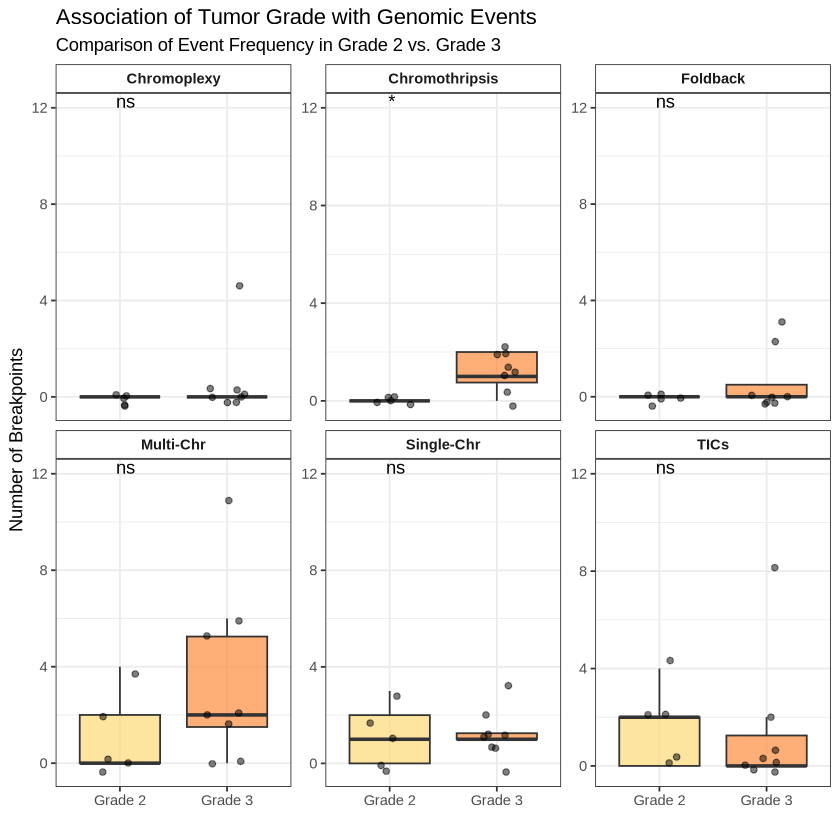

In [42]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(stringr)
library(ggpubr) # For easy statistical comparison labels

# --- 1. PREPARE THE DATA ---
parse_count <- function(text) {
  if (is.na(text) || text == "" || is.logical(text)) return(0)
  length(unique(unlist(str_extract_all(as.character(text), "chr[0-9XY]+"))))
}

# Process counts and join with clinic
grade_comparison_df <- df %>%
  rowwise() %>%
  mutate(
    TICs = parse_count(Templated.Insertion.Chains..TICs..like.complex.insertions),
    Chromothripsis = parse_count(chromothripsis),
    Foldback = parse_count(foldback.translocation),
    `Single-Chr` = parse_count(complex.rearranegment.single.chr),
    `Multi-Chr` = parse_count(complex.rearranegment.multiple.chr),
    Chromoplexy = parse_count(chromoplexy)
  ) %>%
  ungroup() %>%
  inner_join(clinic, by = c("Samples" = "ID")) %>%
  # Filter for only Grade 2 and Grade 3
  filter(Grade %in% c(2, 3)) %>%
  mutate(Grade = paste0("Grade ", Grade))

# Reshape for plotting
plot_long <- grade_comparison_df %>%
  pivot_longer(cols = TICs:Chromoplexy, names_to = "Event_Type", values_to = "Count")

# --- 2. GENERATE THE PLOT ---
ggplot(plot_long, aes(x = Grade, y = Count, fill = Grade)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.5, size = 1.5) +
  # This adds the statistical comparison (P-value) between Grade 2 and 3
  stat_compare_means(method = "wilcox.test", label = "p.signif", label.y = max(plot_long$Count) + 1) +
  facet_wrap(~Event_Type, scales = "free_y") +
  scale_fill_manual(values = c("Grade 2" = "#fed976", "Grade 3" = "#fd8d3c")) +
  theme_bw() +
  labs(title = "Association of Tumor Grade with Genomic Events",
       subtitle = "Comparison of Event Frequency in Grade 2 vs. Grade 3",
       x = "", y = "Number of Breakpoints") +
  theme(legend.position = "none",
        strip.background = element_rect(fill = "white"),
        strip.text = element_text(face = "bold"))

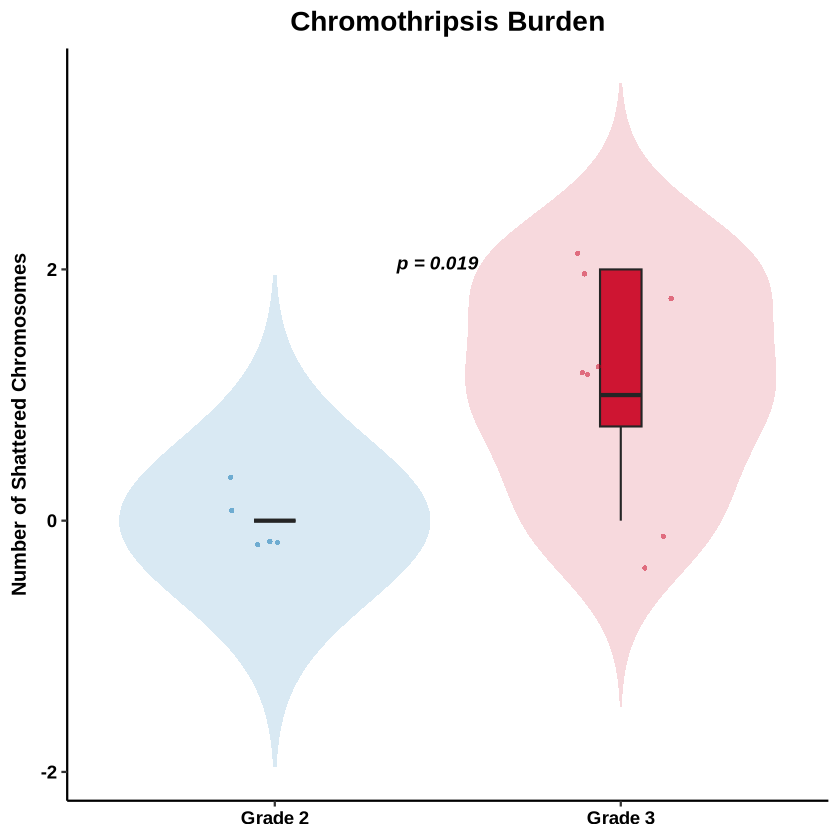

In [52]:
library(ggplot2)
library(dplyr)
library(ggpubr)

# --- 1. CLEAN DATA ---
# Ensure Grade is a factor for proper ordering
plot_data <- grade_comparison_df %>%
  filter(!is.na(Grade)) %>%
  mutate(Grade = factor(Grade, levels = c("Grade 2", "Grade 3")))

# --- 2. HIGH-QUALITY PLOT ---
ggplot(plot_data, aes(x = Grade, y = Chromothripsis, fill = Grade)) +
  # 1. Subtle Violin: Width reflects sample frequency/count
  geom_violin(trim = FALSE, alpha = 0.15, color = NA, scale = "width") +
  
  # 2. Refined Boxplot: Minimalist Nature Style
  geom_boxplot(width = 0.12, 
               outlier.shape = NA, 
               alpha = 0.9, 
               color = "#252525", 
               linewidth = 0.6) +
  
  # 3. High-Quality Jitter: Small, semi-transparent points
  geom_jitter(width = 0.15, 
              size = 1.5, 
              alpha = 0.5, 
              stroke = 0, 
              aes(color = Grade)) +
  
  # 4. Statistical Annotation: Clean P-value bracket
  stat_compare_means(method = "wilcox.test", 
                     label = "p.format", 
                     label.x = 1.4, 
                     size = 4,
                     fontface = "bold.italic") +
  
  # 5. Publication Palette (Cancer Cell Style: Blue vs. Red)
  scale_fill_manual(values = c("Grade 2" = "#0571b0", "Grade 3" = "#ca0020")) +
  scale_color_manual(values = c("Grade 2" = "#0571b0", "Grade 3" = "#ca0020")) +
  
  # 6. Minimalist Theme
  theme_classic(base_size = 14) +
  labs(y = "Number of Shattered Chromosomes", 
       x = NULL,
       title = "Chromothripsis Burden") +
  theme(
    legend.position = "none",
    axis.text = element_text(color = "black", face = "bold"),
    axis.title.y = element_text(face = "bold", size = 12),
    plot.title = element_text(hjust = 0.5, face = "bold")
  )

In [53]:
head(plot_data)

Samples,Templated.Insertion.Chains..TICs..like.complex.insertions,chromothripsis,foldback.translocation,complex.rearranegment.single.chr,complex.rearranegment.multiple.chr,chromoplexy,X,TICs,Chromothripsis,⋯,Single-Chr,Multi-Chr,Chromoplexy,Age,Grade,CDKN2A.B,TP53,ATRX,onco_Alterations,ONT_Alterations
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<fct>,<int>,<int>,<int>,<int>,<int>
3188,chr6,"(chr5,chr14)","(chr20,chr11)",chr13,,,NA,1,2,⋯,1,0,0,NA,Grade 3,NA,NA,NA,16,107
3988,"(chr2,chr5)",,,"chr1,chr2,chr3",,,NA,2,0,⋯,3,0,0,0,Grade 2,2,0,0,17,105
6265D,,chr5,1,"chr18,chr3,chr13","(chr12,chr17)",,NA,0,1,⋯,3,2,0,33,Grade 3,1,0,0,42,87
6266D,,,,chr10,"chr3,chr9",,NA,0,0,⋯,1,2,0,40,Grade 2,1,0,0,28,105
6277A,"(chr1, chr2)(chr9,chr8.chr7)(chr9,chr16),chr12,(chr20,chr8)","chr13,chr2","(chr18,chr14)(chr18,chr4)",chr8,"(chr6,chr10.chr19),(chr10,chr13,chr18)(chr2,chr10,chr6)(chr7,chr8,chr9)(chr12,chr13.chr5)","chr18,chr3,chr7,chr8,chr9",NA,8,2,⋯,1,11,5,40,Grade 3,1,0,0,70,138
6314E,"(chr11.chr22)(chr19,chr14)",,,,,,NA,4,0,⋯,0,0,0,25,Grade 2,2,0,2,18,226
